İlk olarak gerekli kütüphaneleri/modülleri projemize eklememiz gerekiyor. Wisconsin Breast Cancer veri seti, scikit-learn kütüphanesi içinde hazır olarak bulunduğu için işimizi kolaylaştırmak adına veri setini buradan kullanabiliriz.

In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns

# Veri Setini yükleyelim (sci-kit-learn kütüphanesinde aynı veri setinin bir kopyası bulunuyor.)
cancer_data = load_breast_cancer()

# Veri setinin içeriğini daha kolay anlamak için bir DataFrame oluşturalım.
# Özellikler (features) cancer_data.data içinde, sütun isimleri ise cancer_data.feature_names içinde yer alıyor.
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Gerçek etiketleri (iyi huylu/kötü huylu) de DataFrame'e ekleyelim.
# Bu etiketleri kümeleme sırasında kullanmayacağız ama en son değerlendirme yapmak için ihtiyacımız olacak.
df['target'] = cancer_data.target

print("Veri Setinin İlk 5 Satırı:")
print(df.head())

print("\nVeri Seti Hakkında Bilgiler:")
df.info()

Veri Setinin İlk 5 Satırı:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  w

#### ADIM 1: VERİ HAZIRLIĞI

1.1. Sınıf Etiketlerini Ayırma
- Kümeleme denetimsiz öğrenme olduğu için sınıf etiketlerini ayırmamız gerekiyor. 
- Kümeleme algoritması sadece özellik verisini ('X') görecek.
- 'y' değişkenini ise en sonda, modelin ne kadar başarılı olduğunu ölçmek için saklıyoruz.

In [3]:
X = df.drop('target', axis=1)

y = df['target']

1.2. Veriyi Ölçeklendirme (Scaling)
- K-Means ve DBSCAN gibi mesafe tabanlı algoritmalar için bu adım kritiktir.
- Ölçeklendirilmiş verinin başarılı olduğunu görmek için ilk 5 satırını kontrol edelim.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ölçeklendirilmiş Özelliklerin İlk 5 Satırı:")
print(X_scaled[:5])

Ölçeklendirilmiş Özelliklerin İlk 5 Satırı:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+

Bu işlem sayesinde artık mean area gibi devasa sayılarla mean smoothness gibi çok küçük sayılar arasında bir fark kalmadı. Hepsi aynı "dilde" konuşuyor ve K-Means algoritması için eşit derecede öneme sahipler.

#### Adım 2: Küme Sayısı Belirleme (Elbow Yöntemi)

K-Means algoritmasının en büyük zorluğu, ondan kaç tane küme bulmasını isteyeceğimizi (yani "K" değerini) bizim önceden belirlememiz gerekmesidir. Bunu başarabilmek için kullanacağımız teknik: Elbow Yöntemi

1. Modeli K=1, K=2, K=3, ... K=10 için sırayla çalıştırırız.

2. Her bir K değeri için, modelin "hata payını" (teknik olarak inertia veya WCSS denir) hesaplarız. Bu hata, noktaların kendi küme merkezlerine ne kadar uzak olduğunun bir ölçüsüdür. Kümeler ne kadar sıkıysa, hata o kadar düşük olur.

3. Bu sonuçları bir grafiğe dökeriz. Grafikte hatanın düşüş hızının yavaşladığı, bir "dirseğe" benzeyen kırılma noktası, bizim için en ideal K sayısını gösterir.

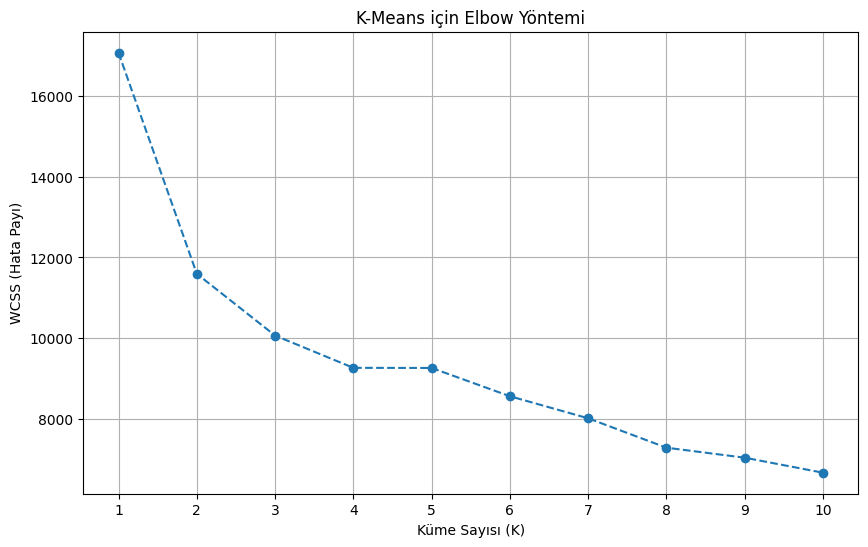

In [5]:
from sklearn.cluster import KMeans

# Farklı K değerleri için WCSS (Within-Cluster Sum of Squares) değerlerini saklamak için bir liste oluşturalım.
wcss = []
k_values = range(1, 11)

for k in k_values:
    # KMeans modelini o anki 'k' değeri ile kuralım
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    # Modeli ölçeklendirilmiş veri üzerinde eğitelim
    kmeans.fit(X_scaled)
    # Modelin wcss (inertia) değerini listeye ekleyelim
    wcss.append(kmeans.inertia_)

# Sonuçları görselleştirelim
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('K-Means için Elbow Yöntemi')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS (Hata Payı)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Bu grafiğe göre en belirgin dirsek K=2 noktasında bulunuyor. İkinci bir potansiyel dirsek ise K=3 olarak düşünülebilir.

Bu nedenle, Elbow Yöntemi bize bu veri seti için en uygun küme sayısının 2 veya 3 olabileceğini öneriyor. Genellikle en keskin kırılma noktası tercih edilir, bu yüzden K=2 ile devam etmek çok mantıklı bir seçim olacaktır.

#### Adım 3: Küme Sayısı Belirleme (Silhouette Skoru)

Bu adımda, Elbow yöntemiyle bulduğumuz K=2 sonucunu, Silhouette Skoru ile teyit edeceğiz. Silhouette skoru, kümelerin ne kadar iyi ayrıştığını ölçer ve en yüksek skoru veren K değeri en iyi olarak kabul edilir.

K=2 için Silhouette Skoru: 0.3447
K=3 için Silhouette Skoru: 0.3152
K=4 için Silhouette Skoru: 0.2742
K=5 için Silhouette Skoru: 0.1645
K=6 için Silhouette Skoru: 0.1451
K=7 için Silhouette Skoru: 0.1470
K=8 için Silhouette Skoru: 0.1619
K=9 için Silhouette Skoru: 0.1439
K=10 için Silhouette Skoru: 0.1471


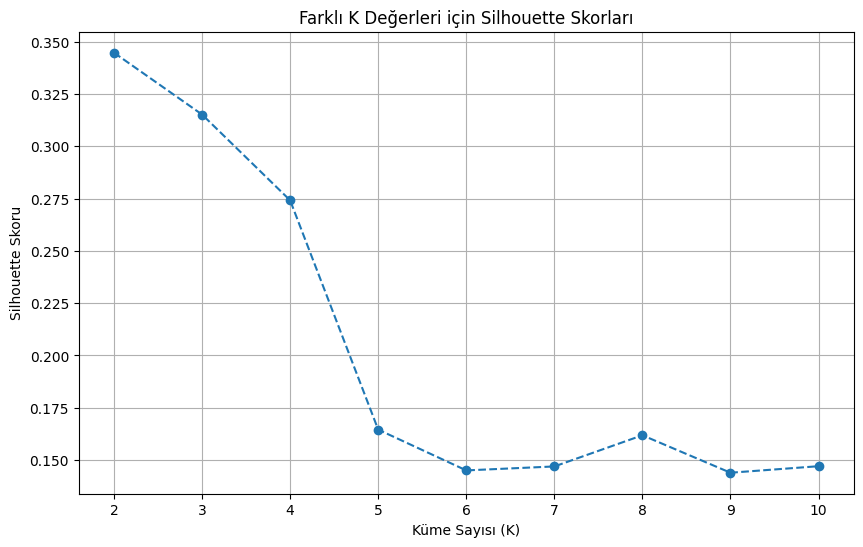

In [7]:
from sklearn.metrics import silhouette_score

# Farklı K değerleri için Silhouette skorlarını saklamak için bir liste
silhouette_scores = []
# Silhouette skoru 1 küme için hesaplanamaz, bu yüzden 2'den başlıyoruz.
k_values = range(2, 11)

for k in k_values:
    # KMeans modelini kuralım
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    
    # Modeli eğitip hangi noktanın hangi kümede olduğunu tahmin edelim
    labels = kmeans.fit_predict(X_scaled)
    
    # O anki k değeri için silhouette skorunu hesaplayalım
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K={k} için Silhouette Skoru: {score:.4f}")

# Skorları görselleştirelim
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.title('Farklı K Değerleri için Silhouette Skorları')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('Silhouette Skoru')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Grafiği incelediğimizde, en yüksek Silhouette skorunun açık bir şekilde K=2 olduğunda elde edildiğini görüyoruz (yaklaşık 0.34 değeriyle). K sayısı arttıkça skorun ne kadar keskin bir şekilde düştüğü de çok net görülüyor.

Bu sonuç, bir önceki adımda Elbow Yöntemi ile yaptığımız tahmini mükemmel bir şekilde doğruluyor. Her iki yöntem de bu veri seti için en uygun küme sayısının 2 olduğunu işaret ediyor.